In [1]:
from static import *

results_static = []  

for threshold_fraction in (0.25,0.5,0.6,0.7,0.8,0.9,0.95):
    for seed_val in range(10):
        print(f"seed={seed_val}, threshold_fraction={threshold_fraction}")
        trained_policy, steps = train(
            n=10, num_traj=50, m=50, eta=0.5, epsilon=1e-4,
            alpha=threshold_fraction,
            grid_size=8, danger=[3,3], goal=[0,6],
            horizon=50, coins=[(1,1),(1,3),(6,2)], seed=seed_val
        )
        results_static.append({
            "threshold_fraction": threshold_fraction,
            "seed": seed_val,
            "steps": steps,
            "policy": trained_policy
        })


seed=0, threshold_fraction=0.25
seed=1, threshold_fraction=0.25
seed=2, threshold_fraction=0.25
seed=3, threshold_fraction=0.25
seed=4, threshold_fraction=0.25
seed=5, threshold_fraction=0.25
seed=6, threshold_fraction=0.25
seed=7, threshold_fraction=0.25
seed=8, threshold_fraction=0.25
seed=9, threshold_fraction=0.25
seed=0, threshold_fraction=0.5
seed=1, threshold_fraction=0.5
seed=2, threshold_fraction=0.5
seed=3, threshold_fraction=0.5
seed=4, threshold_fraction=0.5
seed=5, threshold_fraction=0.5
seed=6, threshold_fraction=0.5
seed=7, threshold_fraction=0.5
seed=8, threshold_fraction=0.5
seed=9, threshold_fraction=0.5
seed=0, threshold_fraction=0.6
seed=1, threshold_fraction=0.6
seed=2, threshold_fraction=0.6
seed=3, threshold_fraction=0.6
seed=4, threshold_fraction=0.6
seed=5, threshold_fraction=0.6
seed=6, threshold_fraction=0.6
seed=7, threshold_fraction=0.6
seed=8, threshold_fraction=0.6
seed=9, threshold_fraction=0.6
seed=0, threshold_fraction=0.7
seed=1, threshold_fraction=0.

In [ ]:
import pickle

with open("results_static.pkl", "wb") as f:
    pickle.dump(results_static, f)

In [3]:
import pandas as pd

df_stat = pd.DataFrame(results_static)
print(df_stat.head())


   threshold_fraction  seed  steps                                 policy
0                0.25     0  10000  <static.Policy object at 0x10476bbd0>
1                0.25     1  10000  <static.Policy object at 0x13534b5d0>
2                0.25     2  10000  <static.Policy object at 0x135264690>
3                0.25     3  10000  <static.Policy object at 0x13532ac90>
4                0.25     4  10000  <static.Policy object at 0x135347c50>


In [5]:
summary_stat = (
    df_stat
    .groupby("threshold_fraction")["steps"]
    .agg(["mean", "std", "min", "max", "median", "count"])
    .reset_index()
)
print(summary_stat)


   threshold_fraction     mean         std    min    max   median  count
0                0.25  10000.0    0.000000  10000  10000  10000.0     10
1                0.50    868.2  103.038073    695   1029    861.5     10
2                0.60   1097.4   64.876293   1016   1206   1088.0     10
3                0.70   1217.5   82.790566   1126   1393   1218.5     10
4                0.80   1217.5   82.790566   1126   1393   1218.5     10
5                0.90   4336.8  427.167102   3724   5054   4354.0     10
6                0.95  10000.0    0.000000  10000  10000  10000.0     10


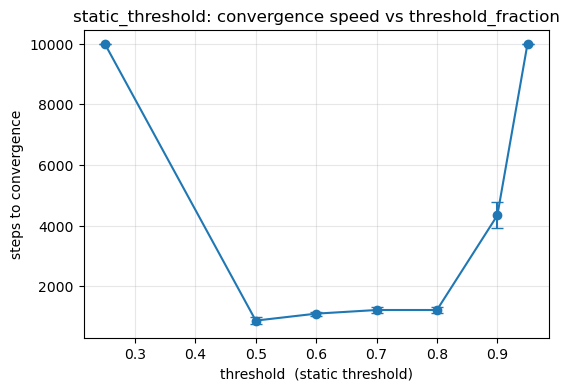

In [8]:
import matplotlib.pyplot as plt

thresholds = summary_stat["threshold_fraction"].values
means  = summary_stat["mean"].values
stds   = summary_stat["std"].values

plt.figure(figsize=(6,4))
plt.errorbar(thresholds, means, yerr=stds, fmt='o-', capsize=4)
plt.xlabel(r"threshold  (static threshold)")
plt.ylabel("steps to convergence")
plt.title("static_threshold: convergence speed vs threshold_fraction")
plt.grid(True, alpha=0.3)
plt.show()
